# U.S. Flight Network Analysis

Federico Maria Brignoli and Felipe Botelho, 2022.

This notebook analyzes U.S. flight operations through descriptive statistics, delay lookup indices, delay classification, airport clustering, and route-network community detection. It keeps the original Colab/Spark setup cells for reference, while the executed version below uses pandas and scikit-learn so the repository can be reviewed without provisioning Spark.

The project focuses on U.S. domestic flight data derived from the Bureau of Transportation Statistics, airport metadata from the public airport-codes dataset, and U.S. public holiday records.

The notebook answers five connected questions:

1. Compare simple Spark and pandas aggregation workflows.
2. Compute operational statistics about airports, days, carriers, periods of day, and delays.
3. Build route-level delay indices that could support a traveller-facing lookup service.
4. Train and evaluate a binary classifier for short versus long departure delays.
5. Cluster airports and detect route-network communities.

The original Spark references remain in commented cells because they document the intended Colab/Spark execution path. The public GitHub showcase path uses local CSV files under `data/` and avoids environment setup side effects.

## Colab setup

The following cell will install Spark, if the notebook is running on COLAB. Before running this cell, you should access the following link [https://drive.google.com/drive/folders/1hylIwkzcOWjYMQW2wWSVRmAN9mEyGToP?usp=sharing](https://drive.google.com/drive/folders/1hylIwkzcOWjYMQW2wWSVRmAN9mEyGToP?usp=sharing)

In [1]:
#Run this cell to install Spark on Colab
'''import os

if 'COLAB_GPU' in os.environ : 
    !apt-get install openjdk-8-jdk-headless
    !pip install pyspark==3.1.2
    !wget https://repos.spark-packages.org/graphframes/graphframes/0.8.2-spark3.1-s_2.12/graphframes-0.8.2-spark3.1-s_2.12.jar
    os.environ['PYSPARK_SUBMIT_ARGS'] = '--jars graphframes-0.8.2-spark3.1-s_2.12.jar pyspark-shell'

    from google.colab import drive
    drive.mount('/content/drive')'''



"import os\n\nif 'COLAB_GPU' in os.environ : \n    !apt-get install openjdk-8-jdk-headless\n    !pip install pyspark==3.1.2\n    !wget https://repos.spark-packages.org/graphframes/graphframes/0.8.2-spark3.1-s_2.12/graphframes-0.8.2-spark3.1-s_2.12.jar\n    os.environ['PYSPARK_SUBMIT_ARGS'] = '--jars graphframes-0.8.2-spark3.1-s_2.12.jar pyspark-shell'\n\n    from google.colab import drive\n    drive.mount('/content/drive')"

## Local setup

For running the group project locally, you should create a directory named **data** in the directory where you have this notebook. Then, you should download to the **data** directory the files in the following link: [https://drive.google.com/drive/folders/1hylIwkzcOWjYMQW2wWSVRmAN9mEyGToP?usp=sharing](https://drive.google.com/drive/folders/1hylIwkzcOWjYMQW2wWSVRmAN9mEyGToP?usp=sharing).

## Initialization

Import libraries. 

In [2]:
import os
import time
import warnings
from pathlib import Path

# Keep Matplotlib cache inside the project so the notebook runs in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib-cache"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

'''
The following imports are needed only for a Spark execution path.
They are intentionally kept commented so the notebook can run locally without Spark.

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.ml.linalg import Vectors
print(pyspark.__version__)
'''

'\nThe following imports are needed only for a Spark execution path.\nThey are intentionally kept commented so the notebook can run locally without Spark.\n\nimport pyspark\nfrom pyspark.sql import SparkSession\nfrom pyspark.sql.types import *\nfrom pyspark.sql.functions import *\nfrom pyspark.ml.linalg import Vectors\nprint(pyspark.__version__)\n'

Let's start spark session and set *log* level to ERROR.

In [3]:
'''spark = SparkSession.builder \
    .master("local") \
    .appName("Group project") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

if 'COLAB_GPU' in os.environ : 
    spark.sparkContext.addPyFile('graphframes-0.8.2-spark3.1-s_2.12.jar')
elif 'DATABRICKS_RUNTIME_VERSION' in os.environ : 
    # Configure Databricks paths or GraphFrames dependencies here if needed
    ;
else:
    spark.sparkContext.addPyFile('/usr/local/spark/jars/graphframes-0.8.1-spark3.0-s_2.12.jar')


spark.sparkContext.setLogLevel("ERROR")'''

'spark = SparkSession.builder     .master("local")     .appName("Group project")     .config("spark.sql.execution.arrow.pyspark.enabled", "true")     .getOrCreate()\n\nif \'COLAB_GPU\' in os.environ : \n    spark.sparkContext.addPyFile(\'graphframes-0.8.2-spark3.1-s_2.12.jar\')\nelif \'DATABRICKS_RUNTIME_VERSION\' in os.environ : \n    # TO BE COMPLETE\n    ;\nelse:\n    spark.sparkContext.addPyFile(\'/usr/local/spark/jars/graphframes-0.8.1-spark3.0-s_2.12.jar\')\n\n\nspark.sparkContext.setLogLevel("ERROR")'

## Data selection

This cell controls the dataset you will be using. Note that this cell will control the path to the files, dependening on the platform you are using to run the code.


In [4]:
# Choose the flight file to analyze. The repository showcase uses sample.csv.
flightsF = "sample.csv"
# flightsF = "complete.csv"
# flightsF = "data-2009.csv"
# flightsF = "data-2010.csv"
# flightsF = "data-2011.csv"
# flightsF = "data-2012.csv"
# flightsF = "data-2013.csv"
# flightsF = "data-2014.csv"
# flightsF = "data-2015.csv"
# flightsF = "data-2016.csv"
# flightsF = "data-2017.csv"
# flightsF = "data-2018.csv"

if "COLAB_GPU" in os.environ:
    # Colab path retained from the original Spark assignment setup.
    FLIGHTS_FILENAME = "/content/drive/MyDrive/group2122/" + flightsF
    AIRPORTS_FILENAME = "/content/drive/MyDrive/group2122/airports.csv"
    HOLIDAYS_FILENAME = "/content/drive/MyDrive/group2122/holidays.csv"
elif "DATABRICKS_RUNTIME_VERSION" in os.environ:
    # Databricks users can adapt these paths to their mounted storage.
    FLIGHTS_FILENAME = "/dbfs/FileStore/group2122/" + flightsF
    AIRPORTS_FILENAME = "/dbfs/FileStore/group2122/airports.csv"
    HOLIDAYS_FILENAME = "/dbfs/FileStore/group2122/holidays.csv"
else:
    FLIGHTS_FILENAME = os.path.join("data", flightsF)
    AIRPORTS_FILENAME = os.path.join("data", "airports.csv")
    HOLIDAYS_FILENAME = os.path.join("data", "holidays.csv")

for filename in [FLIGHTS_FILENAME, AIRPORTS_FILENAME, HOLIDAYS_FILENAME]:
    if not Path(filename).exists() and "COLAB_GPU" not in os.environ and "DATABRICKS_RUNTIME_VERSION" not in os.environ:
        raise FileNotFoundError(f"Required data file not found: {filename}")

print("Flights:", FLIGHTS_FILENAME)
print("Airports:", AIRPORTS_FILENAME)
print("Holidays:", HOLIDAYS_FILENAME)

Flights: data/sample.csv
Airports: data/airports.csv
Holidays: data/holidays.csv


## Datasets

This section describes the datasets you have available for your analysis.

### Flights

The flights dataset, generated from data available at [https://www.transtats.bts.gov/DataIndex.asp](https://www.transtats.bts.gov/DataIndex.asp), includes the following columns:

* FL_DATE: date of the flight (format: yyyy-mm-dd)
* OP_CARRIER: carrier code
* OP_CARRIER_FL_NUM: carrier flight number
* ORIGIN: origin airport (using IATA codes)
* DEST: destination airport (using IATA codes)
* CRS_DEP_TIME: scheduled local departure time (format for all times: hh:mm)
* DEP_TIME: actual departure time
* DEP_DELAY: departure delay, in minutes
* TAXI_OUT: taxi out time
* WHEELS_OFF: actual local wheel off time
* WHEELS_ON: actual local wheel on time
* TAXI_IN: actual local taxi in time
* CRS_ARR_TIME: scheduled local arrival time
* ARR_TIME: actual arrival time
* ARR_DELAY: arrival delay, in minutes
* CANCELLED: 1 if the flight has been cancelled; 0 otherwise
* CANCELLATION_CODE: code of cancelation (A = carrier, B = weather, C = NAS, D = security)
* DIVERTED: 1 if the flight has been diverted; 0 otherwise
* CRS_ELAPSED_TIME: estimated elapsed time
* ACTUAL_ELAPSED_TIME: actual elapsed time
* AIR_TIME: flight time, in minutes
* DISTANCE: flight distance, in miles
* CARRIER_DELAY: delay due to carrier, in minutes
* WEATHER_DELAY: delay due to weather, in minutes
* NAS_DELAY: delay due to NAS, in minutes
* SECURITY_DELAY: delay due to security, in minutes
* LATE_AIRCRAFT_DELAY: delay due to late aircraft, in minutes

The following data files are available:

* complete.csv : complete data set, including data from 2009 to 2018
* sample.csv : sample data set, including data from July 1 to July 15, from years 2009 to 2018
* data-20xx.csv : data set for a particular year

Load the dataset into flightsDF dataframe and register flights under view name **flights**. We are setting the schema programmatically, because inferring the schema in a very large dataframe is slow.


In [5]:
'''
Spark loading path retained for Colab/Spark runs:

flightsSchema = StructType([
    StructField("FL_DATE", DateType()),
    StructField("OP_CARRIER", StringType()),
    StructField("OP_CARRIER_FL_NUM", IntegerType()),
    StructField("ORIGIN", StringType()),
    StructField("DEST", StringType()),
    StructField("CRS_DEP_TIME", StringType()),
    StructField("DEP_TIME", StringType()),
    StructField("DEP_DELAY", IntegerType()),
    StructField("TAXI_OUT", IntegerType()),
    StructField("WHEELS_OFF", StringType()),
    StructField("WHEELS_ON", StringType()),
    StructField("TAXI_IN", IntegerType()),
    StructField("CRS_ARR_TIME", StringType()),
    StructField("ARR_TIME", StringType()),
    StructField("ARR_DELAY", IntegerType()),
    StructField("CANCELLED", IntegerType()),
    StructField("CANCELLATION_CODE", StringType()),
    StructField("DIVERTED", IntegerType()),
    StructField("CRS_ELAPSED_TIME", IntegerType()),
    StructField("ACTUAL_ELAPSED_TIME", IntegerType()),
    StructField("AIR_TIME", IntegerType()),
    StructField("DISTANCE", IntegerType()),
    StructField("CARRIER_DELAY", IntegerType()),
    StructField("WEATHER_DELAY", IntegerType()),
    StructField("NAS_DELAY", IntegerType()),
    StructField("SECURITY_DELAY", IntegerType()),
    StructField("LATE_AIRCRAFT_DELAY", IntegerType())
])
flightsDF = spark.read.option("header", True).schema(flightsSchema).csv(FLIGHTS_FILENAME)
flightsDF.createOrReplaceTempView("flights")
flightsDF.show(3)
'''

FLIGHT_DTYPES = {
    "OP_CARRIER": "category",
    "OP_CARRIER_FL_NUM": "Int32",
    "ORIGIN": "category",
    "DEST": "category",
    "CRS_DEP_TIME": "string",
    "DEP_TIME": "string",
    "DEP_DELAY": "float32",
    "TAXI_OUT": "float32",
    "WHEELS_OFF": "string",
    "WHEELS_ON": "string",
    "TAXI_IN": "float32",
    "CRS_ARR_TIME": "string",
    "ARR_TIME": "string",
    "ARR_DELAY": "float32",
    "CANCELLED": "int8",
    "CANCELLATION_CODE": "string",
    "DIVERTED": "int8",
    "CRS_ELAPSED_TIME": "float32",
    "ACTUAL_ELAPSED_TIME": "float32",
    "AIR_TIME": "float32",
    "DISTANCE": "float32",
    "CARRIER_DELAY": "float32",
    "WEATHER_DELAY": "float32",
    "NAS_DELAY": "float32",
    "SECURITY_DELAY": "float32",
    "LATE_AIRCRAFT_DELAY": "float32",
}

# mySchema keeps the original variable name used later in the assignment notebook.
mySchema = FLIGHT_DTYPES

def read_flights_csv(filename):
    df = pd.read_csv(filename, dtype=FLIGHT_DTYPES)
    df["FL_DATE"] = pd.to_datetime(df["FL_DATE"], errors="coerce")
    return df

start_time = time.time()
flightsDF = read_flights_csv(FLIGHTS_FILENAME)
print(f"Loaded {len(flightsDF):,} flights in {time.time() - start_time:.2f} seconds")
flightsDF.head(3)

Loaded 2,363,605 flights in 3.48 seconds


,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2009-07-01,XE,5660,ORD,ROC,07:17,07:11,-6.0,12.0,07:23,09:39,4.0,09:56,09:43,-13.0,0,<NA>,0,99.0,92.0,76.0,528.0,NaN,NaN,NaN,NaN,NaN
1,2009-07-01,XE,5661,ROC,ORD,09:48,09:43,-5.0,7.0,09:50,10:11,22.0,10:38,10:33,-5.0,0,<NA>,0,110.0,110.0,81.0,528.0,NaN,NaN,NaN,NaN,NaN
2,2009-07-01,XE,5662,ORD,SDF,10:26,10:22,-4.0,9.0,10:31,12:20,7.0,12:50,12:27,-23.0,0,<NA>,0,84.0,65.0,49.0,286.0,NaN,NaN,NaN,NaN,NaN


### Airports

The airports dataset includes the information about US airports - soure: [https://datahub.io/core/airport-codes](https://datahub.io/core/airport-codes).

This dataset includes the following columns:

* ident: identifier
* type: type of airport
* name: name of airport
* elevation_ft: altitude, in feets
* continent: code of continent
* iso_country: coide of country
* iso_regio: code of region
* municipality: city
* gps_code: code of GPS
* iata_code: IATA code of aurport
* local_code: local code of airport
* coordinates: coordinates of airport

Load the dataset into airportDF dataframe and register airports under view name **airports**.


In [6]:
'''
Spark loading path retained for Colab/Spark runs:

airportsDF = spark.read.option("header", True).option("inferSchema", True).csv(AIRPORTS_FILENAME)
airportsDF.createOrReplaceTempView("airports")
airportsDF.show(3)
'''

airportsDF = pd.read_csv(AIRPORTS_FILENAME)
airportsDF.head(3)

,ident,type,name,elevation_ft,continent,iso_country,iso_region,municipality,gps_code,iata_code,local_code,coordinates
0,00A,heliport,Total Rf Heliport,11.0,NaN,US,US-PA,Bensalem,00A,NaN,00A,"-74.93360137939453, 40.07080078125"
1,00AA,small_airport,Aero B Ranch Airport,3435.0,NaN,US,US-KS,Leoti,00AA,NaN,00AA,"-101.473911, 38.704022"
2,00AK,small_airport,Lowell Field,450.0,NaN,US,US-AK,Anchor Point,00AK,NaN,00AK,"-151.695999146, 59.94919968"


Exemplify how you can plot information about airports.

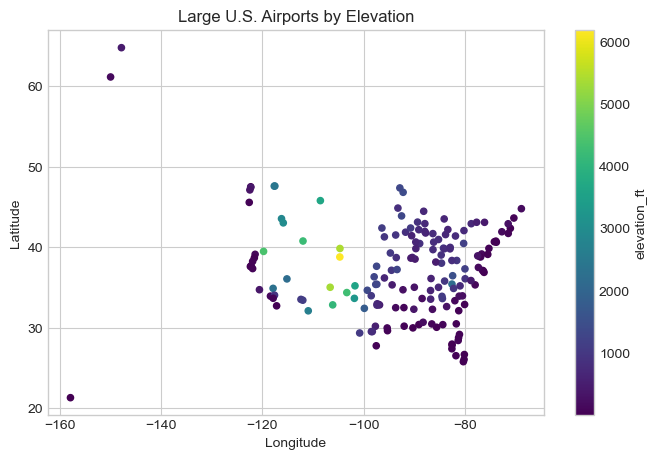

In [7]:
# Example airport-location plot using pandas instead of Spark.
# In this airport-codes file, U.S. rows often have a blank continent field, so country is the reliable filter.
airportLocPD = airportsDF.loc[
    (airportsDF["type"] == "large_airport") & (airportsDF["iso_country"] == "US"),
    ["name", "elevation_ft", "coordinates"],
].copy()

coords = airportLocPD["coordinates"].str.split(",", expand=True)
airportLocPD["lon"] = pd.to_numeric(coords[0], errors="coerce")
airportLocPD["lat"] = pd.to_numeric(coords[1], errors="coerce")
airportLocPD = airportLocPD.dropna(subset=["lon", "lat"])

ax = airportLocPD.plot(x="lon", y="lat", c="elevation_ft", s=20, cmap="viridis", kind="scatter", figsize=(8, 5))
ax.set_title("Large U.S. Airports by Elevation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


### Public holidays

Dates of public holidays in the US.

This dataset includes the following columns:

* Date: date (format: yyyy-mm-dd)
* Holiday: name of the holiday
* WeekDay: day of week
* Month: month (1-12)
* Day: day (1-31)
* Year: year (2002-2021)

Load the dataset into holidaysDF dataframe and register holidays under view name **holidays**.


In [8]:
'''
Spark loading path retained for Colab/Spark runs:

holidaysDF = spark.read.option("header", True).option("inferSchema", True).csv(HOLIDAYS_FILENAME)
holidaysDF.createOrReplaceTempView("holidays")
holidaysDF.show(3)
'''

holidaysDF = pd.read_csv(HOLIDAYS_FILENAME, parse_dates=["Date"])
holidaysDF.head(3)

,Date,Holiday,WeekDay,Month,Day,Year
0,2004-07-04,4th of July,Sunday,7,4,2004
1,2005-07-04,4th of July,Monday,7,4,2005
2,2006-07-04,4th of July,Tuesday,7,4,2006


### Code: Spark

In [9]:
'''start_time = time.time()

flightsSchema = StructType([
    StructField("FL_DATE", DateType()),
    StructField("OP_CARRIER", StringType()),
    StructField("OP_CARRIER_FL_NUM", IntegerType()),
    StructField("ORIGIN", StringType()),
    StructField("DEST", StringType()),
    StructField("CRS_DEP_TIME", StringType()),
    StructField("DEP_TIME", StringType()),
    StructField("DEP_DELAY", IntegerType()),
    StructField("TAXI_OUT", IntegerType()),
    StructField("WHEELS_OFF", StringType()),
    StructField("WHEELS_ON", StringType()),
    StructField("TAXI_IN", IntegerType()),
    StructField("CRS_ARR_TIME", StringType()),
    StructField("ARR_TIME", StringType()),
    StructField("ARR_DELAY", IntegerType()),
    StructField("CANCELLED", IntegerType()),
    StructField("CANCELLATION_CODE", StringType()),
    StructField("DIVERTED", IntegerType()),
    StructField("CRS_ELAPSED_TIME", IntegerType()),
    StructField("ACTUAL_ELAPSED_TIME", IntegerType()),
    StructField("AIR_TIME", IntegerType()),
    StructField("DISTANCE", IntegerType()),
    StructField("CARRIER_DELAY", IntegerType()),
    StructField("WEATHER_DELAY", IntegerType()),
    StructField("NAS_DELAY", IntegerType()),
    StructField("SECURITY_DELAY", IntegerType()),
    StructField("LATE_AIRCRAFT_DELAY", IntegerType())
    ])

flightsDF = spark.read.option("header", True).schema(flightsSchema).csv(FLIGHTS_FILENAME)

flightsDF.createOrReplaceTempView("flights_new")

result = spark.sql("SELECT OP_CARRIER, count(*) AS num_flights FROM flights_new GROUP BY OP_CARRIER")
result.show()

end_time = time.time()
print( "Runtime = " + str(end_time - start_time))'''



'start_time = time.time()\n\nflightsSchema = StructType([\n    StructField("FL_DATE", DateType()),\n    StructField("OP_CARRIER", StringType()),\n    StructField("OP_CARRIER_FL_NUM", IntegerType()),\n    StructField("ORIGIN", StringType()),\n    StructField("DEST", StringType()),\n    StructField("CRS_DEP_TIME", StringType()),\n    StructField("DEP_TIME", StringType()),\n    StructField("DEP_DELAY", IntegerType()),\n    StructField("TAXI_OUT", IntegerType()),\n    StructField("WHEELS_OFF", StringType()),\n    StructField("WHEELS_ON", StringType()),\n    StructField("TAXI_IN", IntegerType()),\n    StructField("CRS_ARR_TIME", StringType()),\n    StructField("ARR_TIME", StringType()),\n    StructField("ARR_DELAY", IntegerType()),\n    StructField("CANCELLED", IntegerType()),\n    StructField("CANCELLATION_CODE", StringType()),\n    StructField("DIVERTED", IntegerType()),\n    StructField("CRS_ELAPSED_TIME", IntegerType()),\n    StructField("ACTUAL_ELAPSED_TIME", IntegerType()),\n    Struc

* Spark timing for `sample.csv`: not executed in this local showcase run.
* Spark timing for `complete.csv`: not executed in this local showcase run.

The Spark code is retained above for Colab/Spark environments, where it can be used to repeat the same carrier-count aggregation on larger datasets.


### Code: Pandas library

In [10]:
start_time = time.time()
carrier_counts = flightsDF.groupby("OP_CARRIER", observed=True).size().rename("num_flights").sort_values(ascending=False)
print(carrier_counts)
print(f"Runtime = {time.time() - start_time:.2f} seconds")


OP_CARRIER
WN    465495
DL    303978
AA    266003
OO    240809
UA    192622
EV    185522
MQ    114668
B6     97885
US     84928
AS     68912
9E     44539
FL     43105
YV     38181
F9     36190
XE     31772
HA     29920
NK     25439
OH     24677
CO     21141
VX     15862
NW     14128
YX     12706
G4      5123
Name: num_flights, dtype: int64
Runtime = 0.02 seconds


* Pandas timing for `sample.csv`: see the executed output above.
* Pandas timing for `complete.csv`: not run in this repository showcase because the full file is large and not required for the public preview.


**Discuss the results you have obtained:**

The pandas workflow completes the simple carrier-count aggregation directly on the local CSV. The Spark cell above is preserved for Colab/Spark environments, but it is not executed in this repository version because the notebook is meant to be reviewable without provisioning a cluster. For this data size, pandas is sufficient for exploratory analysis; Spark becomes more useful when the full multi-year dataset is too large for local memory or when multiple transformations need to be distributed.

## 1. Exploratory Data Analysis

### Top-20 airports with more flights (include the name of the airport)

In [11]:
airport_names = (
    airportsDF.dropna(subset=["iata_code"])
    .drop_duplicates("iata_code")
    .set_index("iata_code")["name"]
)

airport_flight_counts = (
    pd.concat([flightsDF["ORIGIN"].astype("string"), flightsDF["DEST"].astype("string")])
    .value_counts()
    .rename_axis("iata_code")
    .reset_index(name="num_flights")
)
airport_flight_counts["airport_name"] = airport_flight_counts["iata_code"].map(airport_names)
airport_flight_counts.head(20)

,iata_code,num_flights,airport_name
0,ATL,295144,Hartsfield Jackson Atlanta International Airport
1,ORD,230090,Chicago O'Hare International Airport
2,DFW,191254,Dallas Fort Worth International Airport
3,DEN,179855,Denver International Airport
4,LAX,167369,Los Angeles International Airport
5,PHX,127661,Phoenix Sky Harbor International Airport
6,IAH,127206,George Bush Intercontinental Houston Airport
7,SFO,126095,San Francisco International Airport
8,LAS,110673,McCarran International Airport
9,MSP,102971,Minneapolis-St Paul International/Wold-Chamber...


### Top-20 days with more flights

In [12]:
top_days = (
    flightsDF.groupby("FL_DATE")
    .size()
    .rename("num_flights")
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_days

,FL_DATE,num_flights
0,2018-07-13,22022
1,2018-07-12,21966
2,2018-07-09,21956
3,2018-07-11,21736
4,2018-07-10,21628
5,2018-07-15,21262
6,2018-07-08,21251
7,2018-07-06,20393
8,2018-07-01,19985
9,2018-07-02,19727


### Periods with more flights: morning (00:00-11:59, midday 12:00-17:59, evening 18:00-23:59)

In [13]:
def period_from_time(value):
    if pd.isna(value):
        return np.nan
    hour = pd.to_numeric(str(value).split(":")[0], errors="coerce")
    if pd.isna(hour):
        return np.nan
    if hour < 12:
        return "morning"
    if hour < 18:
        return "midday"
    return "evening"

flightsDF["DEP_PERIOD"] = flightsDF["CRS_DEP_TIME"].map(period_from_time)
period_counts = flightsDF.groupby("DEP_PERIOD", observed=True).size().rename("num_flights").sort_values(ascending=False)
period_counts

DEP_PERIOD
morning    981231
midday     865053
evening    517320
Name: num_flights, dtype: int64

### Top-20 airports with longer delays

In [14]:
airport_delay = (
    flightsDF.dropna(subset=["DEP_DELAY"])
    .groupby("ORIGIN", observed=True)
    .agg(avg_departure_delay=("DEP_DELAY", "mean"), num_departures=("DEP_DELAY", "size"))
    .reset_index()
)
# Filter tiny airports so the ranking reflects meaningful operational volume.
airport_delay = airport_delay[airport_delay["num_departures"] >= 100]
airport_delay["airport_name"] = airport_delay["ORIGIN"].astype("string").map(airport_names)
airport_delay.sort_values("avg_departure_delay", ascending=False).head(20)

,ORIGIN,avg_departure_delay,num_departures,airport_name
54,CEC,34.728642,199,Jack Mc Namara Field Airport
204,OTH,26.377104,297,Southwest Oregon Regional Airport
299,MVY,25.058092,241,Martha's Vineyard Airport
321,TTN,22.631098,656,Trenton Mercer Airport
303,GCK,22.600000,180,Garden City Regional Airport
338,PIB,21.621622,111,Hattiesburg Laurel Regional Airport
350,PIE,20.682926,369,St Petersburg Clearwater International Airport
6,ACV,20.384068,841,California Redwood Coast-Humboldt County Airport
95,EWR,20.217031,42722,Newark Liberty International Airport
348,PGD,18.799999,230,Charlotte County Airport


### Top 10 carriers with longer delays

In [15]:
carrier_delay = (
    flightsDF.dropna(subset=["DEP_DELAY"])
    .groupby("OP_CARRIER", observed=True)
    .agg(avg_departure_delay=("DEP_DELAY", "mean"), num_flights=("DEP_DELAY", "size"))
    .sort_values("avg_departure_delay", ascending=False)
    .head(10)
)
carrier_delay

,avg_departure_delay,num_flights
OP_CARRIER,,
G4,20.816416,4995
B6,16.731836,96199
EV,16.373348,179883
UA,16.209217,190233
F9,15.938725,35871
VX,15.003489,15768
NK,14.211006,24985
AA,12.671845,262504
WN,12.620205,461915


### Longer delays by period: morning (00:00-11:59, midday 12:00-17:59, evening 18:00-23:59)


In [16]:
period_delay = (
    flightsDF.dropna(subset=["DEP_DELAY", "DEP_PERIOD"])
    .groupby("DEP_PERIOD", observed=True)
    .agg(avg_departure_delay=("DEP_DELAY", "mean"), median_departure_delay=("DEP_DELAY", "median"), num_flights=("DEP_DELAY", "size"))
    .sort_values("avg_departure_delay", ascending=False)
)
period_delay

,avg_departure_delay,median_departure_delay,num_flights
DEP_PERIOD,,,
evening,20.195084,1.0,507777
midday,14.441039,0.0,852956
morning,4.817322,-2.0,972216


## 2. Build website backend data indices

Assume you want to create a web site to help travellers get information about flight delays. The web site would allow a user to find out information about delays for the flight she want to take. 
The information about delays should include at least 3 statistics - suggestion: the average delay in the same route of the same carrier in the last 7 days, 30 days, 365 days, similar but considering only flights in the same week day, similar but considering flights in the same week day, but excluding holidays, etc.

To support this web site, it would be necessary to build one or more indices that would be used to answer the query of the user.

Write the code to build these indices - for each index, print 5 lines.

In [17]:
# Build route/carrier delay indices at daily granularity. These tables are the kind of lookup
# layer a web service could query after a traveller enters carrier, origin, destination, and date.
holiday_dates = set(pd.to_datetime(holidaysDF["Date"]).dt.date)

index_base = flightsDF.dropna(subset=["FL_DATE", "OP_CARRIER", "ORIGIN", "DEST", "DEP_DELAY"]).copy()
index_base["weekday"] = index_base["FL_DATE"].dt.day_name()
index_base["is_holiday"] = index_base["FL_DATE"].dt.date.isin(holiday_dates)

daily_route_carrier = (
    index_base.groupby(["OP_CARRIER", "ORIGIN", "DEST", "FL_DATE", "weekday"], observed=True)
    .agg(avg_dep_delay=("DEP_DELAY", "mean"), median_dep_delay=("DEP_DELAY", "median"), num_flights=("DEP_DELAY", "size"), is_holiday=("is_holiday", "max"))
    .reset_index()
    .sort_values(["OP_CARRIER", "ORIGIN", "DEST", "FL_DATE"])
)

def add_rolling_windows(group):
    group = group.sort_values("FL_DATE").set_index("FL_DATE")
    for window in [7, 30, 365]:
        rolling = group["avg_dep_delay"].rolling(f"{window}D", closed="left")
        group[f"avg_delay_last_{window}d"] = rolling.mean()
        group[f"observations_last_{window}d"] = rolling.count()
    return group.reset_index()

rolled_groups = []
for _, group in daily_route_carrier.groupby(["OP_CARRIER", "ORIGIN", "DEST"], observed=True, sort=False):
    rolled_groups.append(add_rolling_windows(group))
route_delay_index = pd.concat(rolled_groups, ignore_index=True)

weekday_nonholiday_index = (
    index_base.loc[~index_base["is_holiday"]]
    .groupby(["OP_CARRIER", "ORIGIN", "DEST", "weekday"], observed=True)
    .agg(avg_delay_same_weekday_nonholiday=("DEP_DELAY", "mean"), observations_same_weekday_nonholiday=("DEP_DELAY", "size"))
    .reset_index()
)

web_delay_index = route_delay_index.merge(
    weekday_nonholiday_index,
    on=["OP_CARRIER", "ORIGIN", "DEST", "weekday"],
    how="left",
)

web_delay_index.sort_values(["observations_last_365d", "num_flights"], ascending=False).head(5)

,FL_DATE,OP_CARRIER,ORIGIN,DEST,weekday,avg_dep_delay,median_dep_delay,num_flights,is_holiday,avg_delay_last_7d,observations_last_7d,avg_delay_last_30d,observations_last_30d,avg_delay_last_365d,observations_last_365d,avg_delay_same_weekday_nonholiday,observations_same_weekday_nonholiday
357354,2010-07-02,HA,OGG,HNL,Friday,-1.156250,-2.0,32,False,2.285714,1.0,2.285714,1.0,-4.274677,15.0,0.374517,518.0
357361,2010-07-09,HA,OGG,HNL,Friday,0.187500,-2.0,32,False,-3.695798,7.0,-2.948109,8.0,-3.662338,15.0,0.374517,518.0
354270,2010-07-02,HA,HNL,OGG,Friday,-1.677419,-2.0,31,False,-2.037037,1.0,-2.037037,1.0,-2.560872,15.0,-1.243191,514.0
354277,2010-07-09,HA,HNL,OGG,Friday,-2.064516,-3.0,31,False,-2.942887,7.0,-2.829656,8.0,-2.661231,15.0,-1.243191,514.0
354303,2013-07-05,HA,HNL,OGG,Friday,-3.833333,-4.0,30,False,-3.604064,4.0,-3.604064,4.0,-1.351759,15.0,-1.243191,514.0


#### Discussion

The index is built at route-carrier-day level: carrier, origin, destination, flight date, weekday, daily average delay, median delay, and flight count. Rolling 7-day, 30-day, and 365-day delay statistics are added using only earlier dates (`closed="left"`), which avoids leaking same-day outcomes into a traveller query. A second index stores same-weekday, non-holiday delay averages. In a web application these tables could be stored in a relational database or key-value store keyed by carrier, origin, destination, and date.

## 3. Delay prediction model

Transform the flights data to include a class, depending on the delay - SHORT, LONG - depending on whether the departure delay was less than 10 minutes, or greater or equal to 10 minutes.

Build and evaluate a classification model for the data.


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df = flightsDF.dropna(subset=["DEP_DELAY", "CRS_DEP_TIME", "OP_CARRIER", "ORIGIN", "DEST", "DISTANCE"]).copy()
model_df["DELAY_CLASS"] = np.where(model_df["DEP_DELAY"] >= 10, "LONG", "SHORT")
model_df["DELAY_CLASS_BIN"] = (model_df["DELAY_CLASS"] == "LONG").astype(int)
model_df["CRS_DEP_HOUR"] = pd.to_numeric(model_df["CRS_DEP_TIME"].str.split(":").str[0], errors="coerce")
model_df["DAY_OF_WEEK"] = model_df["FL_DATE"].dt.day_name()
model_df = model_df.dropna(subset=["CRS_DEP_HOUR", "DAY_OF_WEEK"])

# Keep the public showcase fast and reproducible while preserving class balance.
MODEL_SAMPLE_SIZE = 200_000
if len(model_df) > MODEL_SAMPLE_SIZE:
    model_df, _ = train_test_split(
        model_df,
        train_size=MODEL_SAMPLE_SIZE,
        stratify=model_df["DELAY_CLASS_BIN"],
        random_state=42,
    )

model_df[["FL_DATE", "OP_CARRIER", "ORIGIN", "DEST", "CRS_DEP_HOUR", "DISTANCE", "DELAY_CLASS"]].head()

,FL_DATE,OP_CARRIER,ORIGIN,DEST,CRS_DEP_HOUR,DISTANCE,DELAY_CLASS
121466,2009-07-07,US,LAS,DTW,16,1750.0,SHORT
902771,2013-07-06,WN,BWI,BDL,16,283.0,SHORT
2088628,2018-07-02,DL,MCO,ATL,7,404.0,SHORT
361227,2010-07-05,US,CLT,ATL,13,227.0,SHORT
1043093,2013-07-13,US,ORD,PHX,20,1440.0,LONG


In [19]:
feature_columns = ["OP_CARRIER", "ORIGIN", "DEST", "DAY_OF_WEEK", "CRS_DEP_HOUR", "DISTANCE"]
X = model_df[feature_columns]
y = model_df["DELAY_CLASS_BIN"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=2,
    stratify=y,
)

preprocess = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), ["OP_CARRIER", "ORIGIN", "DEST", "DAY_OF_WEEK"]),
        ("numeric", StandardScaler(), ["CRS_DEP_HOUR", "DISTANCE"]),
    ]
)

classifier = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=300, class_weight="balanced")),
    ]
)

classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

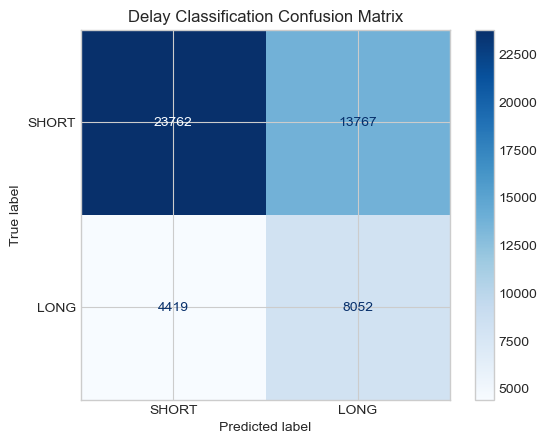

Precision: 0.369
Recall: 0.646
Accuracy: 0.636
              precision    recall  f1-score   support

       SHORT       0.84      0.63      0.72     37529
        LONG       0.37      0.65      0.47     12471

    accuracy                           0.64     50000
   macro avg       0.61      0.64      0.60     50000
weighted avg       0.72      0.64      0.66     50000



In [20]:
cm = confusion_matrix(y_test, y_pred)
display_labels = ["SHORT", "LONG"]
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels).plot(cmap="Blues", values_format="d")
plt.title("Delay Classification Confusion Matrix")
plt.show()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(classification_report(y_test, y_pred, target_names=display_labels))

In [21]:
# Baseline comparison: always predicting the majority class would miss every long delay.
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print(f"Share of LONG delays in test set: {y_test.mean():.3f}")
print(f"Majority-class baseline accuracy: {baseline_accuracy:.3f}")

Share of LONG delays in test set: 0.249
Majority-class baseline accuracy: 0.751


The classifier metrics above should be read against the majority-class baseline, because long delays are less frequent than short delays.


#### Discussion

The target class is `SHORT` when departure delay is under 10 minutes and `LONG` otherwise. The model uses features that are available before departure or during planning: carrier, origin, destination, weekday, scheduled departure hour, and distance. Categorical variables are one-hot encoded and numeric variables are standardized before fitting a balanced logistic regression model.

The class distribution is imbalanced, so accuracy alone is not sufficient. Precision and recall for the `LONG` class show how well the model identifies materially delayed flights. The model is useful as a lightweight baseline for the assignment, but a production delay predictor would need richer weather, aircraft rotation, congestion, and recent operations data.

## 4. Airports clustering

Consider we want to cluster airports depending on their properties, such as average number of flights per day, delays, cancellations, etc.

Measure the quality of your clustering result.

In [22]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

airport_stat_DF = (
    flightsDF.dropna(subset=["FL_DATE", "ORIGIN"])
    .groupby("ORIGIN", observed=True)
    .agg(
        num_departures=("ORIGIN", "size"),
        active_days=("FL_DATE", "nunique"),
        mean_dep_delay=("DEP_DELAY", "mean"),
        cancellation_rate=("CANCELLED", "mean"),
    )
    .reset_index()
)
airport_stat_DF["mean_flights_day"] = airport_stat_DF["num_departures"] / airport_stat_DF["active_days"]
airport_stat_DF["airport_name"] = airport_stat_DF["ORIGIN"].astype("string").map(airport_names)
airport_stat_DF = airport_stat_DF.dropna(subset=["mean_flights_day", "mean_dep_delay", "cancellation_rate"])
airport_stat_DF.sort_values("num_departures", ascending=False).head(10)

,ORIGIN,num_departures,active_days,mean_dep_delay,cancellation_rate,mean_flights_day,airport_name
18,ATL,147589,135,14.074560,0.007623,1093.251852,Hartsfield Jackson Atlanta International Airport
202,ORD,115049,135,15.348704,0.019392,852.214815,Chicago O'Hare International Airport
81,DFW,95641,135,15.190754,0.015360,708.451852,Dallas Fort Worth International Airport
80,DEN,89928,135,13.777366,0.008507,666.133333,Denver International Airport
151,LAX,83685,135,10.070189,0.010193,619.888889,Los Angeles International Airport
212,PHX,63831,135,9.112985,0.006580,472.822222,Phoenix Sky Harbor International Airport
133,IAH,63593,135,15.146978,0.013807,471.059259,George Bush Intercontinental Houston Airport
247,SFO,63054,135,12.786592,0.023805,467.066667,San Francisco International Airport
150,LAS,55333,135,11.932911,0.007916,409.874074,McCarran International Airport
190,MSP,51510,135,9.026416,0.007086,381.555556,Minneapolis-St Paul International/Wold-Chamber...


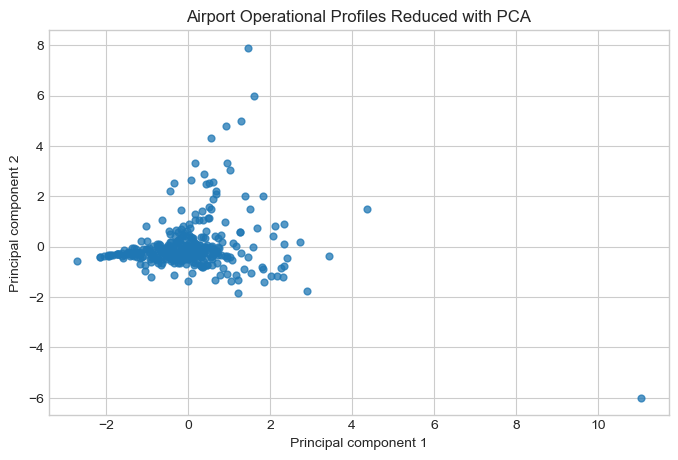

Explained variance ratio: [0.406 0.36 ]


In [23]:
cluster_features = airport_stat_DF[["mean_flights_day", "mean_dep_delay", "cancellation_rate"]]
scaled_airport_features = StandardScaler().fit_transform(cluster_features)

pca = PCA(n_components=2, random_state=42)
reduced_pca = pca.fit_transform(scaled_airport_features)
airports_pca_df = pd.DataFrame(reduced_pca, columns=["principal_component_1", "principal_component_2"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(airports_pca_df["principal_component_1"], airports_pca_df["principal_component_2"], s=24, alpha=0.75)
ax.set_title("Airport Operational Profiles Reduced with PCA")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
plt.show()

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

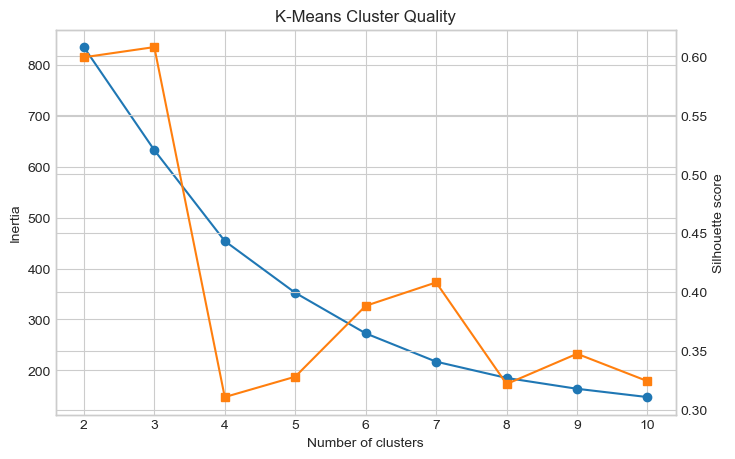

,k,inertia,silhouette
0,2,834.603169,0.599260
1,3,632.434407,0.607913
2,4,453.976624,0.310851
3,5,352.424318,0.328144
4,6,272.768413,0.388303
5,7,217.208372,0.408171
6,8,185.260086,0.321928
7,9,163.986923,0.347608
8,10,147.706854,0.324381


In [24]:
inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(scaled_airport_features)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_airport_features, labels))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(list(k_values), inertias, marker="o", label="Inertia")
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Inertia")
ax2 = ax1.twinx()
ax2.plot(list(k_values), silhouette_scores, marker="s", color="tab:orange", label="Silhouette")
ax2.set_ylabel("Silhouette score")
ax1.set_title("K-Means Cluster Quality")
plt.show()

quality_table = pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette": silhouette_scores})
quality_table

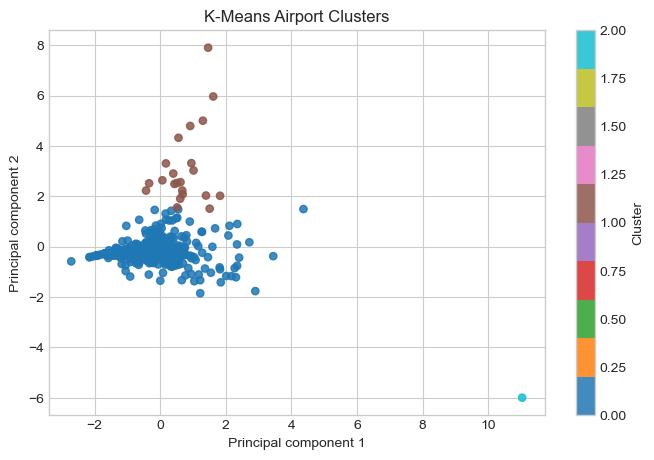

,airports,avg_flights_day,avg_delay,avg_cancellation_rate
cluster,,,,
0,346,22.448,8.850,0.018
1,22,453.375,13.145,0.014
2,1,1.000,29.500,0.333


In [25]:
N_CLUSTERS = 3
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=42)
airport_stat_DF["cluster"] = kmeans.fit_predict(scaled_airport_features)
airports_pca_df["cluster"] = airport_stat_DF["cluster"].values

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    airports_pca_df["principal_component_1"],
    airports_pca_df["principal_component_2"],
    c=airports_pca_df["cluster"],
    cmap="tab10",
    s=28,
    alpha=0.85,
)
ax.set_title("K-Means Airport Clusters")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.show()

cluster_summary = (
    airport_stat_DF.groupby("cluster")
    .agg(
        airports=("ORIGIN", "count"),
        avg_flights_day=("mean_flights_day", "mean"),
        avg_delay=("mean_dep_delay", "mean"),
        avg_cancellation_rate=("cancellation_rate", "mean"),
    )
    .round(3)
)
cluster_summary

#### Discussion

Airports are represented by mean daily departures, mean departure delay, and cancellation rate. These features summarize scale, reliability, and disruption. PCA is used only for visualization; clustering is performed on the standardized original features. The elbow curve and silhouette scores provide a quality check for candidate cluster counts, and the final three-cluster solution separates airports with different operational profiles.

## 5. Airport network clustering

We now want to find communities of airports, i.e., airports that are connected based on the flights that exist.

Propose an algorithm to solve this problem and plot the communities as a graph. Run the program with and without GPU support.

In [26]:
import networkx as nx
from networkx.algorithms import community

# Build an undirected weighted route graph from airport pairs. The weight is the number of observed flights.
route_counts = (
    flightsDF.groupby(["ORIGIN", "DEST"], observed=True)
    .size()
    .rename("weight")
    .reset_index()
)

route_graph = nx.Graph()
for row in route_counts.itertuples(index=False):
    origin, dest, weight = str(row.ORIGIN), str(row.DEST), int(row.weight)
    if origin != dest:
        route_graph.add_edge(origin, dest, weight=route_graph.get_edge_data(origin, dest, {}).get("weight", 0) + weight)

print(f"Graph nodes: {route_graph.number_of_nodes():,}")
print(f"Graph edges: {route_graph.number_of_edges():,}")

Graph nodes: 369
Graph edges: 3,374


In [27]:
# Greedy modularity is deterministic, available in NetworkX, and scales well enough for this route graph.
communities = list(community.greedy_modularity_communities(route_graph, weight="weight"))
community_lookup = {airport: idx for idx, airports in enumerate(communities) for airport in airports}
modularity = community.modularity(route_graph, communities, weight="weight")

print(f"Detected communities: {len(communities)}")
print(f"Modularity: {modularity:.3f}")
for idx, airports in enumerate(communities[:8]):
    print(f"Community {idx}: {len(airports)} airports; examples: {sorted(list(airports))[:10]}")

Detected communities: 4
Modularity: 0.268
Community 0: 161 airports; examples: ['ABE', 'ABY', 'ACY', 'AGS', 'ALB', 'ALO', 'APN', 'ART', 'ATL', 'ATW']
Community 1: 120 airports; examples: ['ABQ', 'ACK', 'ACV', 'ADK', 'ADQ', 'AKN', 'ANC', 'ASE', 'BET', 'BFF']
Community 2: 61 airports; examples: ['ABI', 'ACT', 'AEX', 'AMA', 'AUS', 'BKG', 'BPT', 'BRO', 'BTR', 'CLL']
Community 3: 27 airports; examples: ['ABR', 'AZA', 'BIS', 'BJI', 'BRD', 'CID', 'DIK', 'DLH', 'DSM', 'FAR']


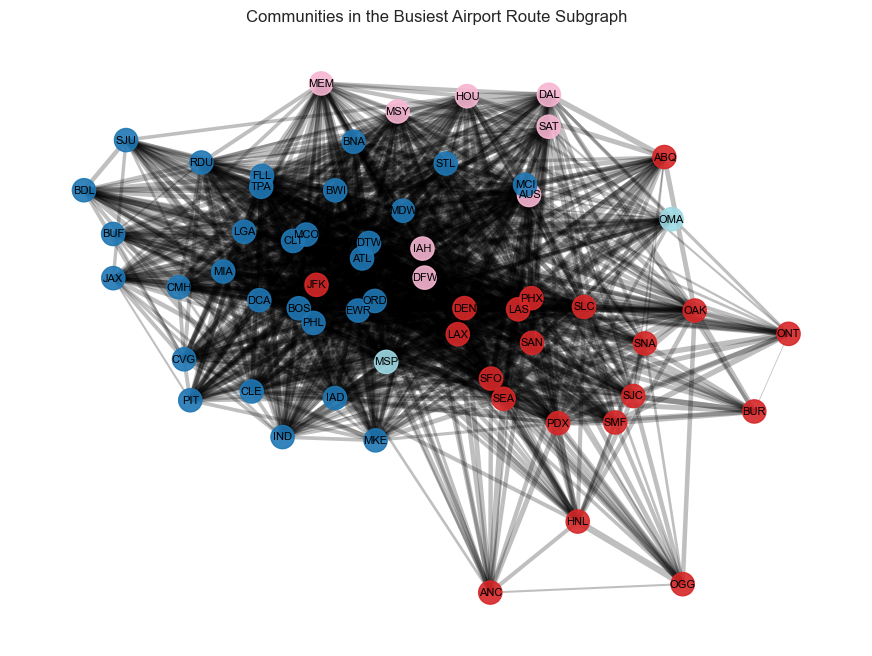

In [28]:
# Plot the busiest subgraph so the visualization remains readable in a notebook.
top_airports = airport_flight_counts.head(60)["iata_code"].astype(str).tolist()
plot_graph = route_graph.subgraph(top_airports).copy()
node_colors = [community_lookup.get(node, -1) for node in plot_graph.nodes()]
edge_widths = [0.2 + np.log1p(plot_graph[u][v]["weight"]) / 2 for u, v in plot_graph.edges()]

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(plot_graph, seed=42, weight="weight", k=0.35)
nx.draw_networkx_nodes(plot_graph, pos, node_color=node_colors, cmap="tab20", node_size=280, alpha=0.9)
nx.draw_networkx_edges(plot_graph, pos, width=edge_widths, alpha=0.25)
nx.draw_networkx_labels(plot_graph, pos, font_size=8)
plt.title("Communities in the Busiest Airport Route Subgraph")
plt.axis("off")
plt.show()

#### Discussion

Airport communities are detected from a weighted route graph where nodes are airport IATA codes and edge weights count flights between two airports. The notebook uses NetworkX greedy modularity community detection because it is available in the local environment and avoids the optional `igraph`, GraphFrames, or GPU stack. The modularity score measures how much more densely connected the detected communities are compared with a random graph with the same degree structure. For larger production runs, the same graph formulation could be moved to Spark GraphFrames or RAPIDS cuGraph.

## Conclusion

The analysis shows how the same flight dataset can support operational summaries, traveller-facing delay lookup indices, predictive modelling, airport clustering, and network community detection. The pandas-first implementation makes the notebook easy to run in a public repository, while the preserved Spark and Colab setup cells document the original distributed-computing path for larger data. The strongest practical outputs are the route-carrier delay index and the network view of airport communities; the delay classifier is best interpreted as a baseline that needs richer real-time features before production use.